24RB1074　半田悠人

## 課題１：データ生成

In [102]:
import numpy as np
import matplotlib.pyplot as plt
 
w = np.random.randn(1, 1)

def generate_dataset(m, w):

    X = np.random.uniform(0, 1, (m, 1))
    
    e = np.random.randn(m, 1) * 0.1
    
    y = X @ w + e
    
    return X, y

X_D, y_D = generate_dataset(100, w)
X_E, y_E = generate_dataset(100, w)

### 課題2-1：線形回帰とプロット

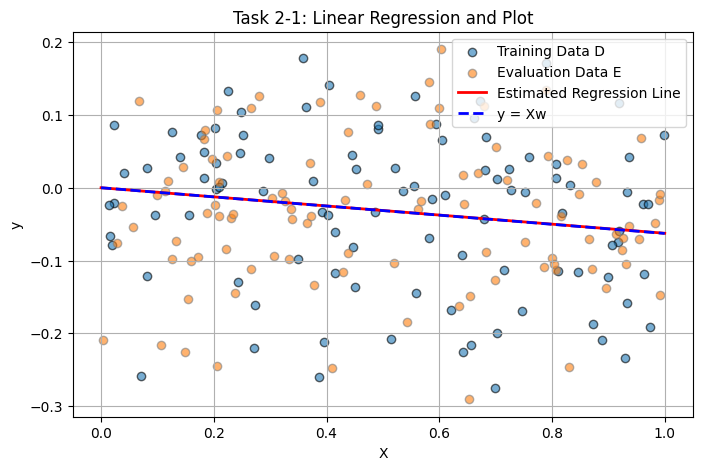

真の傾き w: -0.062750
推定された傾き w_hat: -0.062508


In [103]:
# セル3で作った訓練データ D で線形回帰
w_hat, _, _, _ = np.linalg.lstsq(X_D, y_D, rcond=None)

# 回帰直線を可視化
x_line = np.linspace(0, 1, 100).reshape(-1, 1)
y_line = x_line @ w_hat
y_true_line = x_line @ w

plt.figure(figsize=(8, 5))
plt.scatter(X_D, y_D, label='Training Data D', alpha=0.6, edgecolor='k')
plt.scatter(X_E, y_E, label='Evaluation Data E', alpha=0.6, edgecolor='gray')
plt.plot(x_line, y_line, color='red', linewidth=2, label='Estimated Regression Line')
plt.plot(x_line, y_true_line, color='blue', linestyle='--', linewidth=2, label='y = Xw')
plt.title('Task 2-1: Linear Regression and Plot')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

print(f"真の傾き w: {w[0, 0]:.6f}")
print(f"推定された傾き w_hat: {w_hat[0, 0]:.6f}")

### 課題2-2：データ数を増やして二乗誤差の変化を見る

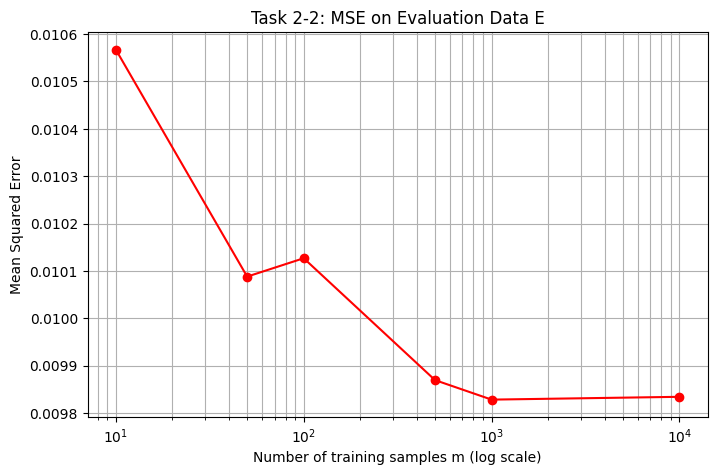

In [104]:
# データ数 m を変えて訓練データを作り、Eでの平均二乗誤差を比較
m_values = [10, 50, 100, 500, 1000, 10000]
mse_values = []
w_hats = []

for m in m_values:
    X_D_m, y_D_m = generate_dataset(m, w)
    w_hat_m, _, _, _ = np.linalg.lstsq(X_D_m, y_D_m, rcond=None)
    y_hat_E_m = X_E @ w_hat_m

    # Eでの(平均)二乗誤差を計算
    mse_m = np.mean((y_E - y_hat_E_m) ** 2)

    mse_values.append(mse_m)
    w_hats.append(w_hat_m[0, 0])

plt.figure(figsize=(8, 5))
plt.plot(m_values, mse_values, marker='o', color='red')
plt.xscale('log')
plt.title('Task 2-2: MSE on Evaluation Data E')
plt.xlabel('Number of training samples m (log scale)')
plt.ylabel('Mean Squared Error')
plt.grid(True, which='both')
plt.show()

### 課題2-3：データ数を増やして$\hat{w}$の変化を見る

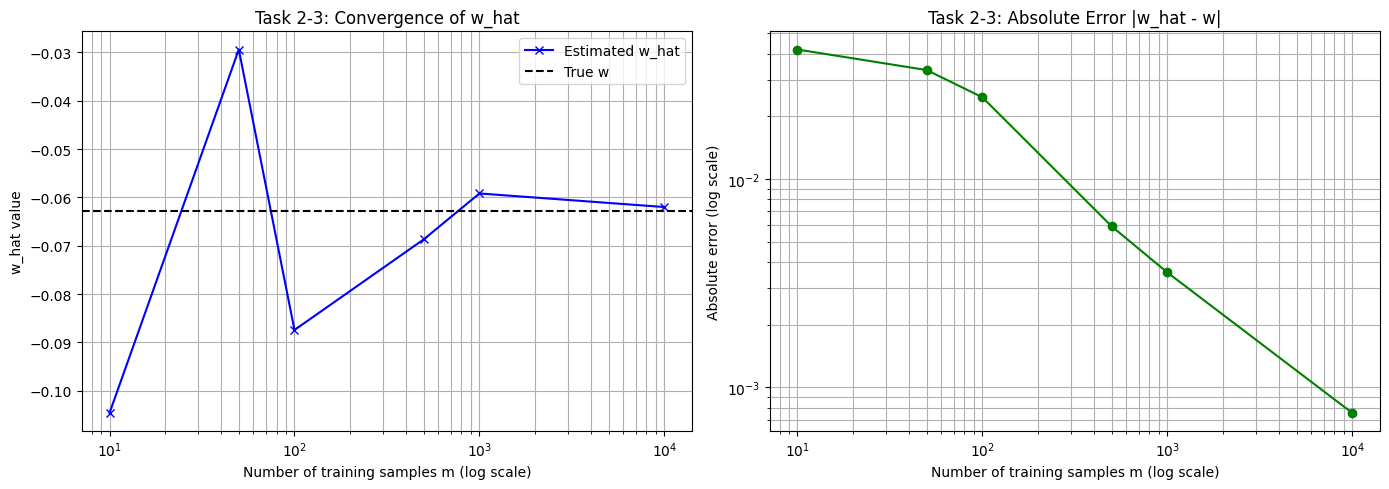

In [105]:
w_true = float(w[0, 0])
w_errors = np.abs(np.array(w_hats) - w_true)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(m_values, w_hats, marker='x', color='blue', label='Estimated w_hat')
axes[0].axhline(w_true, color='black', linestyle='--', label='True w')
axes[0].set_xscale('log')
axes[0].set_title('Task 2-3: Convergence of w_hat')
axes[0].set_xlabel('Number of training samples m (log scale)')
axes[0].set_ylabel('w_hat value')
axes[0].legend()
axes[0].grid(True, which='both')

axes[1].plot(m_values, w_errors, marker='o', color='green')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Task 2-3: Absolute Error |w_hat - w|')
axes[1].set_xlabel('Number of training samples m (log scale)')
axes[1].set_ylabel('Absolute error (log scale)')
axes[1].grid(True, which='both')

plt.tight_layout()
plt.show()

## 課題３：データセットdiabetesで線形回帰

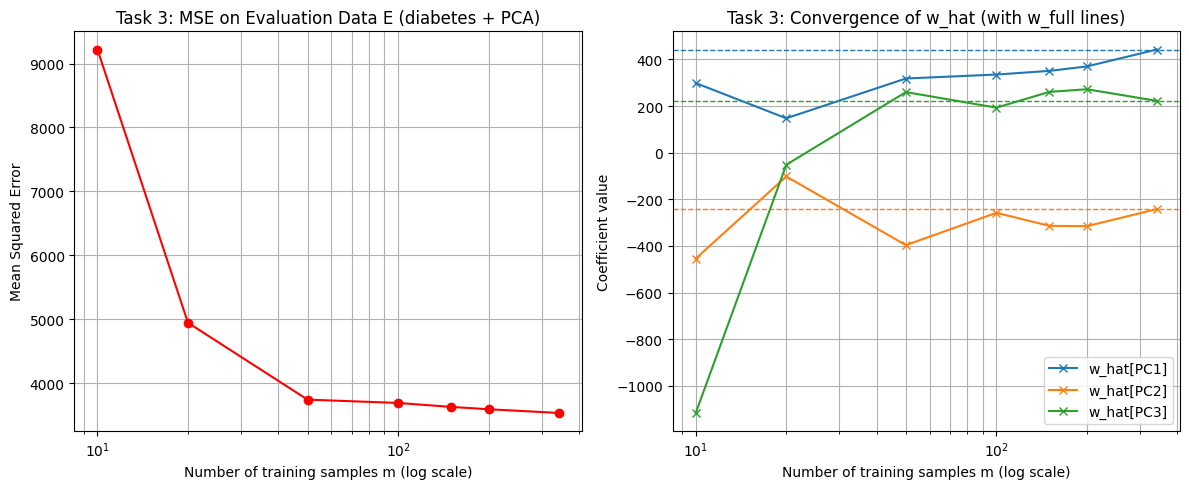

In [106]:
from sklearn.datasets import load_diabetes
from sklearn.decomposition import PCA

# diabetesデータを読み込み、中心化
X_db, y_db = load_diabetes(return_X_y=True)
X_db = X_db - np.mean(X_db, axis=0)
y_db = y_db - np.mean(y_db)

# PCAで次元削減（3次元に圧縮）
pca = PCA(n_components=3)
X_db_pca = pca.fit_transform(X_db)

# 評価データ E と訓練データプール D_pool に分割
num_eval = 100
X_E_db_pca = X_db_pca[-num_eval:]
y_E_db = y_db[-num_eval:]
X_pool_db_pca = X_db_pca[:-num_eval]
y_pool_db = y_db[:-num_eval]

# m を変えながら回帰し、MSEとw_hatを記録
m_values_db = [10, 20, 50, 100, 150, 200, len(X_pool_db_pca)]
mse_values_db = []
w_hats_db = []

for m in m_values_db:
    X_D_m_db = X_pool_db_pca[:m]
    y_D_m_db = y_pool_db[:m]

    w_hat_m_db, _, _, _ = np.linalg.lstsq(X_D_m_db, y_D_m_db, rcond=None)
    y_hat_E_m_db = X_E_db_pca @ w_hat_m_db
    mse_m_db = np.mean((y_E_db - y_hat_E_m_db) ** 2)

    mse_values_db.append(mse_m_db)
    w_hats_db.append(w_hat_m_db)

w_hats_db = np.array(w_hats_db)
w_full_db, _, _, _ = np.linalg.lstsq(X_pool_db_pca, y_pool_db, rcond=None)

# MSE変化とw_hat収束を可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(m_values_db, mse_values_db, marker='o', color='red')
axes[0].set_xscale('log')
axes[0].set_title('Task 3: MSE on Evaluation Data E (diabetes + PCA)')
axes[0].set_xlabel('Number of training samples m (log scale)')
axes[0].set_ylabel('Mean Squared Error')
axes[0].grid(True, which='both')

for i in range(w_hats_db.shape[1]):
    line, = axes[1].plot(m_values_db, w_hats_db[:, i], marker='x', label=f'w_hat[PC{i+1}]')
    axes[1].axhline(w_full_db[i], linestyle='--', linewidth=1, color=line.get_color())

axes[1].set_xscale('log')
axes[1].set_title('Task 3: Convergence of w_hat (with w_full lines)')
axes[1].set_xlabel('Number of training samples m (log scale)')
axes[1].set_ylabel('Coefficient value')
axes[1].grid(True, which='both')
axes[1].legend()

plt.tight_layout()
plt.show()

## 全体の考察

### 課題1から課題3を通じた観察

1. 訓練データ数と推定精度の関係

    課題2-2と2-3のグラフから、訓練データ数 $m$ が増加するにつれて、評価データ E でのMSEが減少し、推定パラメータ $\hat{w}$ が真の値 $w$ に収束する。

2. 学習曲線の形状

- $m$ が小さい場合：MSEが高く、推定パラメータが真の値から大きく外れている
- $m$ が中程度の場合：MSEが急速に低下し、$\hat{w}$ が収束に向かう
- $m$ が大きい場合：MSEはほぼ安定し、$\hat{w}$ は真の値に十分に近い

3. 高次元データへの対応

    課題3で diabetes データセットに対してPCAで3次元に削減することで、可視化が容易になり、収束の様子を直観的に理解できた。

## 結論

線形回帰における推定パラメータの収束は、訓練データ数に強く依存し、少数のデータからの推定は不安定であり、データが増えることで推定精度が向上する。

## AI利用について

本演習課題の実施にあたり、以下の通りAIを活用した。

* 関数の調査・学習
    * 実現したい処理を行える関数の選定から、必要な引数、内部の処理内容、返り値についてAIに質問し、理解を深めた上で実装と確認を行った。
    * 調査した主な関数・メソッド: `linspace`, `reshape`, `lstsq`, `load_diabetes`

* グラフのプロット（Copilotの活用）
    * 線形回帰の結果や、データ数を変えたときのMSEの変化、推定係数 `w_hat` の収束の様子を可視化するためのコード作成にCopilotを活用した。
    * 生成されたコードと出力されたグラフは自分で内容の確認と検証を行った。

* マークダウンの書き方
    * マークダウンでの数式、箇条書きのやり方を聞いた